# Assignment 1: Neural Networks

**Student ID:** 2022320302  
**Name:** 원준서

**Grading (100 points)**

| Item | Topic | Points |
|---|---|---:|
| 1.1–1.3 | NumPy affine layers and activation analysis | 13 |
| 2.1–2.3 | NumPy two-layer network | 18 |
| 3.1–3.2 | NumPy training and generalization analysis | 9 |
| 4.1–4.2 | PyTorch FNN model | 14 |
| 5.1–5.2 | FNN configuration and optimizer | 5 |
| 6.1 | FNN training loop | 8 |
| 7.1–7.2 | CNN model | 12 |
| 8.1–8.2 | CNN configuration and optimizer | 5 |
| 9.1 | CNN training loop | 7 |
| 10.1 | Filter visualization | 3 |
| 11.1 | FNN vs. CNN analysis | 6 |
| **Total** |  | **100** |          




**Part 1** builds a fully-connected network twice: first a two-layer net in
numpy (layer -> model -> train, backprop by hand), then again in PyTorch
using `nn.Module` and autograd.

**Part 2** implements a convolutional network in PyTorch.

The last cell asks you to compare the PyTorch FNN and the CNN.

**Lecture References**

> Statements under `Lecture Connection` are reproduced or
> lightly reformatted from *Lec01 Foundations of Deep Learning* without changing
> their meaning. Page numbers refer to the PDF pages.
> Implementation and experiment guides provide details that are not stated explicitly in the lecture slides.

## Colab Setup: Download CIFAR-10

Run the following cell once before Part 1. It downloads and extracts CIFAR-10
directly in the Colab runtime, so no external shell script or local file is required.
Re-running the cell is safe: it skips the download when the extracted dataset exists.

In [1]:
%%bash
set -euo pipefail

DATASET_DIR="datasets"
CIFAR_DIR="$DATASET_DIR/cifar-10-batches-py"
ARCHIVE="$DATASET_DIR/cifar-10-python.tar.gz"
URL="https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"

mkdir -p "$DATASET_DIR"
if [ ! -d "$CIFAR_DIR" ]; then
  echo "Downloading CIFAR-10..."
  curl -L --fail --show-error "$URL" -o "$ARCHIVE"
  tar -xzf "$ARCHIVE" -C "$DATASET_DIR"
  rm "$ARCHIVE"
  echo "CIFAR-10 is ready."
else
  echo "CIFAR-10 is already available; skipping download."
fi

CIFAR-10 is already available; skipping download.


## Part 1: Fully-Connected Network

### Section 1: NumPy Implementation

Implement one modular layer, a two-layer network built from it, and the
training loop that fits it to CIFAR-10 -- all backprop written by hand in
numpy.     
`relu_forward/backward` and `softmax_loss` are
provided.

#### Setup

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """returns relative error"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))


#### Provided: Gradient-checking Utilities

The following two functions compare gradients computed via backprop against numerical gradients. **This is provided code -- no need to modify it.**

In [3]:
def eval_numerical_gradient(f, x, verbose=False, h=1e-5):
    """a naive implementation of numerical gradient of f at x"""
    fx = f(x)
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix = it.multi_index
        oldval = x[ix]
        x[ix] = oldval + h
        fxph = f(x)
        x[ix] = oldval - h
        fxmh = f(x)
        x[ix] = oldval

        grad[ix] = (fxph - fxmh) / (2 * h)
        if verbose:
            print(ix, grad[ix])
        it.iternext()
    return grad


def eval_numerical_gradient_array(f, x, df, h=1e-5):
    """Evaluate a numeric gradient for a function that accepts a numpy array and returns a numpy array."""
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix = it.multi_index
        oldval = x[ix]
        x[ix] = oldval + h
        pos = f(x).copy()
        x[ix] = oldval - h
        neg = f(x).copy()
        x[ix] = oldval

        grad[ix] = np.sum((pos - neg) * df) / (2 * h)
        it.iternext()
    return grad


#### Provided: CIFAR-10 data utilities

In [4]:
import os
import pickle

# The functions below define the CIFAR-10 loading and preprocessing pipeline.
# The actual download and memory-intensive loading step is deferred until 3.1,
# so the layer and gradient tests can run first without requiring the dataset.

def _load_CIFAR_batch(filename):
    with open(filename, 'rb') as f:
        datadict = pickle.load(f, encoding='latin1')
        X = datadict['data']
        Y = datadict['labels']
        # Keep CIFAR-10 in float32; plain 'float' usually means float64 and
        # roughly doubles the memory required by the full training set.
        X = X.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1).astype(np.float32)
        Y = np.array(Y)
        return X, Y


def _load_CIFAR10(root):
    xs, ys = [], []
    for b in range(1, 6):
        X, Y = _load_CIFAR_batch(os.path.join(root, 'data_batch_%d' % b))
        xs.append(X)
        ys.append(Y)
    X_train = np.concatenate(xs)
    y_train = np.concatenate(ys)
    X_test, y_test = _load_CIFAR_batch(os.path.join(root, 'test_batch'))
    return X_train, y_train, X_test, y_test


def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000, subtract_mean=True):
    cifar10_dir = os.path.join('datasets', 'cifar-10-batches-py')
    X_train, y_train, X_test, y_test = _load_CIFAR10(cifar10_dir)

    X_val = X_train[num_training:num_training + num_validation]
    y_val = y_train[num_training:num_training + num_validation]
    X_train = X_train[:num_training]
    y_train = y_train[:num_training]
    X_test = X_test[:num_test]
    y_test = y_test[:num_test]

    if subtract_mean:
        mean_image = np.mean(X_train, axis=0)
        X_train = X_train - mean_image
        X_val = X_val - mean_image
        X_test = X_test - mean_image

    X_train = X_train.transpose(0, 3, 1, 2).copy()
    X_val = X_val.transpose(0, 3, 1, 2).copy()
    X_test = X_test.transpose(0, 3, 1, 2).copy()

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
    }

#### Question 1.1: Affine Forward Pass [code] (4 points)

Implement the `affine_forward` function below.

**Lecture Connection**

   > Correct tensor shapes are essential for neural-network computation. Many
   > implementation errors are actually shape mismatches. **(Lecture, p. 19)**

   > A basic layer can be written as: `z = Wx + b`. Both `W` and `b` can be learned
   > from data. A neural network is built from repeated parameterized transformations.
   > **(Lecture, p. 22)**

**Notes**


* The lecture presents `z = Wx + b` for a single linear transformation on p. 22.
* The lecture uses the term *linear transformation* for this operation.
* Because the bias term is included, it is mathematically affine; this assignment therefore uses
function names such as `affine_forward` and `affine_backward`.
* For batched computation, p. 19 uses `X` with shape `(B, D)`, `W` with shape
`(D, H)`, and `XW` with shape `(B, H)`.
* This assignment follows that batched
arrangement but uses `N` for batch size and `M` for a generic affine output
dimension.


   | Lecture symbol | Assignment symbol | Meaning |
   |---|---|---|
   | `B` | `N` | Batch size |
   | `D` | `D` | Input feature dimension |
   | `H` | `M` | Output dimension of a generic affine transformation |

* In `TwoLayerNet`, the symbol `H` is used again for the hidden dimension; it is
the output dimension of the first affine transformation.

**Implementation Guide**

   1. The minibatch size `N` is `x.shape[0]`. Flatten each example into one row,
      giving `x` shape `(N, D)`. You do not need to modify the original array.
   2. The matrix product of the flattened input and `w` must have shape `(N, M)`.
      Adding `b` with shape `(M,)` uses NumPy broadcasting.
   3. Keep the original `(x, w, b)` in `cache` so the backward pass can restore
      the original input shape.

> **Shape check:** `(N, D) @ (D, M) + (M,) -> (N, M)`

Run the test below after implementation. A relative error below `1e-9` is expected.

In [5]:
def affine_forward(x, w, b):
    """
    Computes the forward pass for an affine (fully-connected) layer.

    The input x has shape (N, d_1, ..., d_k) and contains a minibatch of N
    examples, where each example x[i] has shape (d_1, ..., d_k). We will
    reshape each input into a vector of dimension D = d_1 * ... * d_k, and
    then transform it to an output vector of dimension M.

    Inputs:
    - x: A numpy array containing input data, of shape (N, d_1, ..., d_k)
    - w: A numpy array of weights, of shape (D, M)
    - b: A numpy array of biases, of shape (M,)

    Returns a tuple of:
    - out: output, of shape (N, M)
    - cache: (x, w, b)
    """
    out = None
    ###########################################################################
    # TODO 1.1 (4 points): Implement the affine forward pass. Store the result #
    # in `out`. Reshape each input example into one row before multiplication. #
    ###########################################################################
    N = x.shape[0]
    x_flat = x.reshape(N, -1)          # (N, D)
    out = x_flat @ w + b               # (N, M)
    ###########################################################################
    #                             END OF YOUR CODE                            #
    ###########################################################################
    cache = (x, w, b)
    return out, cache


In [6]:
# Test the affine_forward function

num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

# Compare your output with ours. The error should be around e-9 or less.
print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))


Testing affine_forward function:
difference:  9.769848888397517e-10


#### Question 1.2: Affine Backward Pass [code] (6 points)

Implement `affine_backward` and test it using numerical gradient checking.

**Lecture Connection**

> Then the influence of `x` on `z` is obtained by multiplying local derivatives
> along the path. The chain rule therefore provides the mathematical foundation
> for backpropagation. **(Lecture, p. 29)**

> Backpropagation computes gradients of the loss with respect to model parameters.
> It works backward through the computational graph. **(Lecture, p. 32)**

**Implementation Guide**

Treat the forward pass as `out = x_flat @ w + b`, then express the derivative
with respect to each input as a matrix product.

- `dx`: propagate `dout` through `w`, then restore the original `x.shape`
- `dw`: combine the flattened input and `dout`, summing contributions from the batch
- `db`: sum over the batch axis (`axis=0`) for each output dimension

> **Shape check:** `dx.shape == x.shape`, `dw.shape == w.shape`, and
> `db.shape == b.shape`. If you get stuck, write down every matrix shape first.

The relative error against the numerical gradient should be about `1e-10` or lower.

In [7]:
def affine_backward(dout, cache):
    """
    Computes the backward pass for an affine layer.

    Inputs:
    - dout: Upstream derivative, of shape (N, M)
    - cache: Tuple of:
      - x: Input data, of shape (N, d_1, ... d_k)
      - w: Weights, of shape (D, M)
      - b: Biases, of shape (M,)

    Returns a tuple of:
    - dx: Gradient with respect to x, of shape (N, d1, ..., d_k)
    - dw: Gradient with respect to w, of shape (D, M)
    - db: Gradient with respect to b, of shape (M,)
    """
    x, w, b = cache
    dx, dw, db = None, None, None
    ###########################################################################
    # TODO 1.2 (6 points): Implement the affine backward pass.                  #
    ###########################################################################
    N = x.shape[0]
    x_flat = x.reshape(N, -1)          # (N, D)
    dx = (dout @ w.T).reshape(x.shape) # (N, D) -> original x shape
    dw = x_flat.T @ dout               # (D, M)
    db = dout.sum(axis=0)              # (M,)
    ###########################################################################
    #                             END OF YOUR CODE                            #
    ###########################################################################
    return dx, dw, db


In [8]:
# Test the affine_backward function
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

# The error should be around e-10 or less
print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))


Testing affine_backward function:
dx error:  5.399100368651805e-11
dw error:  9.904211865398145e-11
db error:  2.4122867568119087e-11


#### Provided: ReLU

`relu_forward`/`relu_backward` are implemented for you -- `TwoLayerNet` below needs them.

**Derivative Convention**

* ReLU is not differentiable at `x = 0`.
* This assignment uses derivative 0 at
that point, as implemented by the mask `(x > 0)`.
* Thus the provided backward
function uses derivative 0 for `x <= 0` and derivative 1 for `x > 0`.

In [9]:
def relu_forward(x):
    """
    Computes the forward pass for a layer of rectified linear units (ReLUs).

    Input:
    - x: Inputs, of any shape

    Returns a tuple of:
    - out: Output, of the same shape as x
    - cache: x
    """
    out = np.maximum(0, x)
    cache = x
    return out, cache


In [10]:
# Test the relu_forward function

x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)

out, _ = relu_forward(x)
correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

# Compare your output with ours. The error should be on the order of e-8
print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))


Testing relu_forward function:
difference:  4.999999798022158e-08


In [11]:
def relu_backward(dout, cache):
    """
    Computes the backward pass for a layer of rectified linear units (ReLUs).

    Input:
    - dout: Upstream derivatives, of any shape
    - cache: Input x, of same shape as dout

    Returns:
    - dx: Gradient with respect to x

    Convention: ReLU is not differentiable at x = 0; this implementation
    assigns derivative 0 at that point.
    """
    x = cache
    dx = dout * (x > 0)
    return dx


In [12]:
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

# The error should be on the order of e-12
print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))


Testing relu_backward function:
dx error:  3.2756349136310288e-12


#### Question 1.3: Activation Gradient Analysis [written] (3 points)
---
`relu_forward`/`relu_backward` are provided above, but
different activation functions can behave very differently during
backpropagation.     
Assume that Leaky ReLU uses negative slope `alpha = 0.01`.    
For each activation below, answer both questions:

- Can its derivative become **exactly zero**? If so, for which inputs?
- Can its derivative become **very small but nonzero**? If so, for which inputs?
- For ReLU, distinguish the mathematical derivative at `x = 0` from the
  derivative convention used by `relu_backward` above.

1. Sigmoid
2. ReLU
3. Leaky ReLU

---

$\color{blue}{\textit Your Answer:}$
<!-- ANSWER_START: 1.3 -->
1. Sigmoid

The derivative of sigmoid is σ(x)(1 − σ(x)), and its value is always between 0 and 0.25. It never becomes exactly zero for any finite x. However, when |x| is large, σ(x) gets very close to 0 or 1, so the derivative becomes very small (but still not zero). This is the reason sigmoid can cause the vanishing gradient problem.

2. ReLU

The derivative is 1 when x > 0 and 0 when x < 0, so it is exactly zero for all negative inputs. It never becomes a small nonzero value, because it is always either 0 or 1. Mathematically, ReLU is not differentiable at x = 0, since the left derivative (0) and the right derivative (1) are different. The provided relu_backward uses the mask (x > 0), so in the code the derivative at x = 0 is simply treated as 0.

3. Leaky ReLU (alpha = 0.01)

The derivative is 1 when x > 0 and 0.01 when x < 0, so it never becomes exactly zero. For negative inputs the derivative is small but nonzero (0.01), so a unit with negative input still gets some gradient and can keep learning.
<!-- ANSWER_END: 1.3 -->

---

#### Provided: Affine-ReLU Function Composition

**Lecture Connection**

> Deep networks repeatedly compose functions. Forward computation evaluates these
> functions from input to output. Backpropagation will later move through the same
> structure in the opposite direction. **(Lecture, p. 24)**

**Notes**

* `affine_relu_forward` composes the affine and ReLU functions into one reusable
operation.     
* `affine_relu_backward` applies their backward passes in reverse order.    
* The `TwoLayerNet` implementation below uses this composition.

In [13]:
def affine_relu_forward(x, w, b):
    """
    Compose an affine transformation followed by a ReLU.

    Inputs:
    - x: Input to the affine layer
    - w, b: Weights for the affine layer

    Returns a tuple of:
    - out: Output from the ReLU
    - cache: Object to give to the backward pass
    """
    a, fc_cache = affine_forward(x, w, b)
    out, relu_cache = relu_forward(a)
    cache = (fc_cache, relu_cache)
    return out, cache


def affine_relu_backward(dout, cache):
    """
    Backward pass for the affine-ReLU function composition.
    """
    fc_cache, relu_cache = cache
    da = relu_backward(dout, relu_cache)
    dx, dw, db = affine_backward(da, fc_cache)
    return dx, dw, db


In [14]:
np.random.seed(231)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

# Relative error should be around e-10 or less
print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))


Testing affine_relu_forward and affine_relu_backward:
dx error:  2.299579177309368e-11
dw error:  8.162011105764925e-11
db error:  7.826724021458994e-12


#### Provided: Softmax Cross-Entropy Loss

**Terminology**
  - **Logits:** Raw, unnormalized outputs from the final affine transformation.
    The code also calls these values `scores`.
  - **Probabilities:** Values obtained by applying softmax to the logits. Each value
    is nonnegative, and the probabilities for one example sum to 1.
  - **Predicted class:** The class index selected by `argmax`. Taking `argmax` of
    the logits or the softmax probabilities gives the same class index.
  - **Prediction:** The lecture uses this as a general term for model output. In this
    assignment, use `logits`, `probabilities`, or `predicted class` when the specific
    meaning matters.

The provided `softmax_loss` receives logits, converts them to probabilities
internally, and computes the cross-entropy loss.

In [15]:
def softmax_loss(x, y):
    """
    Computes the loss and gradient for softmax classification.

    Inputs:
    - x: Input logits, of shape (N, C), where x[i, j] is the unnormalized
      score for the jth class for the ith input.
    - y: Vector of labels, of shape (N,) where y[i] is the label for x[i] and
      0 <= y[i] < C

    Returns a tuple of:
    - loss: Scalar giving the loss
    - dx: Gradient of the loss with respect to x
    """
    shifted = x - np.max(x, axis=1, keepdims=True)
    sum_exp = np.sum(np.exp(shifted), axis=1, keepdims=True)
    log_probs = shifted - np.log(sum_exp)
    probs = np.exp(log_probs)
    N = x.shape[0]
    loss = -np.sum(log_probs[np.arange(N), y]) / N
    dx = probs.copy()
    dx[np.arange(N), y] -= 1
    dx /= N
    return loss, dx


In [16]:
np.random.seed(231)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)


dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)
loss, dx = softmax_loss(x, y)

# Test softmax_loss function. Loss should be close to 2.3 and dx error should be around e-8
print('\nTesting softmax_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))



Testing softmax_loss:
loss:  2.302545844500738
dx error:  9.384673161989355e-09


### Section 2: NumPy Two-Layer Network

#### Question 2.1-2.3: Two-layer Network [code] (4 points, 5 points, 9 points)
Complete the implementation of the `TwoLayerNet` class below. Read through it to make sure you understand the API.     
You can run the cell below to test your implementation.

**Lecture Connection**

> The computation proceeds sequentially: Receive input `x`; compute the first
> linear transformation; apply a nonlinear transformation `g`; compute the output;
> produce prediction. This process is called a forward pass. **(Lecture, p. 23)**

> Forward computation evaluates these functions from input to output.
> Backpropagation will later move through the same structure in the opposite
> direction. **(Lecture, p. 24)**

> A loss function measures disagreement between prediction and target. Training
> attempts to reduce the loss. **(Lecture, p. 13)**

**Implementation Guide and Point Breakdown**

The model forward path is `affine -> ReLU -> affine -> logits`.

During training,`softmax_loss` converts the logits to probabilities internally and computes the cross-entropy loss.      
At test time, `model.loss(X)` returns logits (called `scores`in the code), and `argmax(scores)` gives the predicted class.      

Implement and test the following parts separately.

1. **Question 2.1 — Parameter initialization (4 points):**
   * Determine the shapes of `W1`, `b1`, `W2`, and `b2`.
   * Initialize weights from a zero-centered Gaussian with standard deviation `weight_scale`, and initialize biases to zero.
2. **Question 2.2 — Forward pass (5 points):**
   * Use `affine_relu_forward` for the hidden layer and `affine_forward` for the output layer. Keep both caches.
   * When `y is None`, return only the scores so forward can be tested independently.
3. **Question 2.3 — Loss and backward pass (9 points):**
   * Add the L2 loss of both weight matrices to the data loss from `softmax_loss` using
   $L = L_{data} + \frac{1}{2}\lambda(\lVert W_1\rVert_2^2 + \lVert W_2\rVert_2^2)$.
   * Under this convention, the regularization gradient for a weight matrix is
   $\lambda W$. Do not regularize biases.
   * Propagate gradients in reverse
   order and add the L2 gradients to `W1` and `W2`.

> **Recommended debugging order:** initialization assertions -> score assertion ->
> loss assertion -> numerical gradient for each parameter. Finish each stage before
> moving to the next one.

In [17]:
class TwoLayerNet(object):
    """
    A two-layer fully-connected neural network with ReLU nonlinearity and
    softmax cross-entropy loss that uses a modular layer design. We assume an
    input dimension of D, a hidden dimension of H, and perform classification
    over C classes.

    The forward architecture is affine - ReLU - affine, which produces logits.
    Softmax cross-entropy is applied only when computing the training loss.

    Note that this class does not implement gradient descent; instead, it
    will interact with a separate Solver object that is responsible for running
    optimization.

    The learnable parameters of the model are stored in the dictionary
    self.params that maps parameter names to numpy arrays.
    """

    def __init__(
        self,
        input_dim=3 * 32 * 32,
        hidden_dim=100,
        num_classes=10,
        weight_scale=1e-3,
        reg=0.0,
    ):
        """
        Initialize a new network.

        Inputs:
        - input_dim: An integer giving the size of the input
        - hidden_dim: An integer giving the size of the hidden layer
        - num_classes: An integer giving the number of classes to classify
        - weight_scale: Scalar giving the standard deviation for random
          initialization of the weights.
        - reg: Scalar giving L2 regularization strength.
        """
        self.params = {}
        self.reg = reg

        ############################################################################
        # TODO 2.1 (4 points): Initialize the weights and biases of the two-layer net. #
        # Initialize weights from a Gaussian centered at 0.0 with standard          #
        # deviation `weight_scale`, and initialize biases to zero.                  #
        # initialized to zero. All weights and biases should be stored in the      #
        # dictionary self.params, with first layer weights                         #
        # and biases using the keys 'W1' and 'b1' and second layer                 #
        # weights and biases using the keys 'W2' and 'b2'.                         #
        ############################################################################
        D, H, C = input_dim, hidden_dim, num_classes
        self.params['W1'] = weight_scale * np.random.randn(D, H)
        self.params['b1'] = np.zeros(H)
        self.params['W2'] = weight_scale * np.random.randn(H, C)
        self.params['b2'] = np.zeros(C)
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

    def loss(self, X, y=None):
        """
        Compute loss and gradient for a minibatch of data.

        Inputs:
        - X: Array of input data of shape (N, d_1, ..., d_k)
        - y: Array of labels, of shape (N,). y[i] gives the label for X[i].

        Returns:
        If y is None, then run a test-time forward pass of the model and return:
        - scores: Array of shape (N, C) giving classification scores, where
          scores[i, c] is the classification score for X[i] and class c.

        If y is not None, then run a training-time forward and backward pass and
        return a tuple of:
        - loss: Scalar value giving the loss
        - grads: Dictionary with the same keys as self.params, mapping parameter
          names to gradients of the loss with respect to those parameters.
        """
        scores = None
        ############################################################################
        # TODO 2.2 (5 points): Implement the forward pass for the two-layer net.      #
        # Compute the logits for X and store them in `scores`.                       #
        ############################################################################
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        h1, cache1 = affine_relu_forward(X, W1, b1)     # (N, H)
        scores, cache2 = affine_forward(h1, W2, b2)     # (N, C) logits
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

        # If y is None then we are in test mode so just return scores
        if y is None:
            return scores

        loss, grads = 0, {}
        ############################################################################
        # TODO 2.3 (9 points): Implement loss and backward pass. Store the loss       #
        # in the loss variable and gradients in the grads dictionary. Compute data #
        # loss using the provided softmax cross-entropy loss, and make sure that   #
        # self.params[k]. Don't forget to add L2 regularization!                   #
        #                                                                          #
        # NOTE: To ensure that your implementation matches ours and you pass the   #
        # automated tests, make sure that your L2 regularization includes a factor #
        # of 0.5 to simplify the expression for the gradient.                      #
        ############################################################################
        loss, dscores = softmax_loss(scores, y)
        loss += 0.5 * self.reg * (np.sum(W1 * W1) + np.sum(W2 * W2))

        dh1, dW2, db2 = affine_backward(dscores, cache2)
        _, dW1, db1 = affine_relu_backward(dh1, cache1)

        grads['W1'] = dW1 + self.reg * W1
        grads['b1'] = db1
        grads['W2'] = dW2 + self.reg * W2
        grads['b2'] = db2
        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

        return loss, grads

    def save(self, fname):
        """Save model parameters."""
        fname = fname if fname.endswith('.npy') else fname + '.npy'
        fpath = os.path.join('saved', fname)
        os.makedirs(os.path.dirname(fpath), exist_ok=True)
        np.save(fpath, self.params)
        print(fname, 'saved.')

    def load(self, fname):
        """Load model parameters."""
        fname = fname if fname.endswith('.npy') else fname + '.npy'
        fpath = os.path.join('saved', fname)
        if not os.path.exists(fpath):
            print(fname, 'not available.')
            return False
        else:
            self.params = np.load(fpath, allow_pickle=True).item()
            print(fname, 'loaded.')
            return True

In [18]:
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

print('Testing initialization ... ')
W1_std = abs(model.params['W1'].std() - std)
b1 = model.params['b1']
W2_std = abs(model.params['W2'].std() - std)
b2 = model.params['b2']
assert W1_std < std / 10, 'First layer weights do not seem right'
assert np.all(b1 == 0), 'First layer biases do not seem right'
assert W2_std < std / 10, 'Second layer weights do not seem right'
assert np.all(b2 == 0), 'Second layer biases do not seem right'

print('Testing test-time forward pass ... ')
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T
scores = model.loss(X)
correct_scores = np.asarray(
  [[11.53165108,  12.2917344,   13.05181771,  13.81190102,  14.57198434, 15.33206765,  16.09215096],
   [12.05769098,  12.74614105,  13.43459113,  14.1230412,   14.81149128, 15.49994135,  16.18839143],
   [12.58373087,  13.20054771,  13.81736455,  14.43418138,  15.05099822, 15.66781506,  16.2846319 ]])
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, 'Problem with test-time forward pass'

print('Testing training loss (no regularization)')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, 'Problem with training-time loss'

model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, 'Problem with regularization loss'

# Errors should be around e-7 or less
for reg in [0.0, 0.7]:
  print('Running numeric gradient check with reg = ', reg)
  model.reg = reg
  loss, grads = model.loss(X, y)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))


Testing initialization ... 
Testing test-time forward pass ... 
Testing training loss (no regularization)
Running numeric gradient check with reg =  0.0
W1 relative error: 1.52e-08


W2 relative error: 3.21e-10
b1 relative error: 8.37e-09
b2 relative error: 4.33e-10
Running numeric gradient check with reg =  0.7
W1 relative error: 2.53e-07


W2 relative error: 2.85e-08
b1 relative error: 1.56e-08
b2 relative error: 7.76e-10


#### Provided: Solver

**Lecture Connection**

> Backpropagation computes gradients. Optimization uses those gradients to change
> parameters. Backpropagation is not Gradient Descent. **(Lecture, p. 35)**

The provided `Solver` keeps these two responsibilities separate: the model computes
loss and gradients, while the update rule changes the model parameters.

In [19]:
def sgd(w, dw, config=None):
    """
    Performs vanilla stochastic gradient descent.

    config format:
    - learning_rate: Scalar learning rate.
    """
    if config is None:
        config = {}
    config.setdefault('learning_rate', 1e-2)
    w -= config['learning_rate'] * dw
    return w, config


_UPDATE_RULES = {'sgd': sgd}


class Solver(object):
    """
    A Solver encapsulates all the logic necessary for training classification
    models. The Solver performs stochastic gradient descent using different
    update rules defined in optim.py.

    The solver accepts both training and validataion data and labels so it can
    periodically check classification accuracy on both training and validation
    data to watch out for overfitting.

    To train a model, you will first construct a Solver instance, passing the
    model, dataset, and various options (learning rate, batch size, etc) to the
    constructor. You will then call the train() method to run the optimization
    procedure and train the model.

    After the train() method returns, model.params will contain the parameters
    that performed best on the validation set over the course of training.
    In addition, the instance variable solver.loss_history will contain a list
    of all losses encountered during training and the instance variables
    solver.train_acc_history and solver.val_acc_history will be lists of the
    accuracies of the model on the training and validation set at each epoch.

    Example usage might look something like this:

    data = {
      'X_train': # training data
      'y_train': # training labels
      'X_val': # validation data
      'y_val': # validation labels
    }
    model = MyAwesomeModel(hidden_size=100, reg=10)
    solver = Solver(model, data,
                    update_rule='sgd',
                    optim_config={
                      'learning_rate': 1e-4,
                    },
                    lr_decay=0.95,
                    num_epochs=5, batch_size=200,
                    print_every=100)
    solver.train()


    A Solver works on a model object that must conform to the following API:

    - model.params must be a dictionary mapping string parameter names to numpy
      arrays containing parameter values.

    - model.loss(X, y) must be a function that computes training-time loss and
      gradients, and test-time classification scores, with the following inputs
      and outputs:

      Inputs:
      - X: Array giving a minibatch of input data of shape (N, d_1, ..., d_k)
      - y: Array of labels, of shape (N,) giving labels for X where y[i] is the
        label for X[i].

      Returns:
      If y is None, run a test-time forward pass and return:
      - scores: Array of shape (N, C) giving classification scores for X where
        scores[i, c] gives the score of class c for X[i].

      If y is not None, run a training time forward and backward pass and
      return a tuple of:
      - loss: Scalar giving the loss
      - grads: Dictionary with the same keys as self.params mapping parameter
        names to gradients of the loss with respect to those parameters.
    """

    def __init__(self, model, data, **kwargs):
        """
        Construct a new Solver instance.

        Required arguments:
        - model: A model object conforming to the API described above
        - data: A dictionary of training and validation data containing:
          'X_train': Array, shape (N_train, d_1, ..., d_k) of training images
          'X_val': Array, shape (N_val, d_1, ..., d_k) of validation images
          'y_train': Array, shape (N_train,) of labels for training images
          'y_val': Array, shape (N_val,) of labels for validation images

        Optional arguments:
        - update_rule: A string giving the name of an update rule in optim.py.
          Default is 'sgd'.
        - optim_config: A dictionary containing hyperparameters that will be
          passed to the chosen update rule. Each update rule requires different
          hyperparameters (see optim.py) but all update rules require a
          'learning_rate' parameter so that should always be present.
        - lr_decay: A scalar for learning rate decay; after each epoch the
          learning rate is multiplied by this value.
        - batch_size: Size of minibatches used to compute loss and gradient
          during training.
        - num_epochs: The number of epochs to run for during training.
        - print_every: Integer; training losses will be printed every
          print_every iterations.
        - verbose: Boolean; if set to false then no output will be printed
          during training.
        - num_train_samples: Number of training samples used to check training
          accuracy; default is 1000; set to None to use entire training set.
        - num_val_samples: Number of validation samples to use to check val
          accuracy; default is None, which uses the entire validation set.
        - checkpoint_name: If not None, then save model checkpoints here every
          epoch.
        """
        self.model = model
        self.X_train = data["X_train"]
        self.y_train = data["y_train"]
        self.X_val = data["X_val"]
        self.y_val = data["y_val"]

        # Unpack keyword arguments
        self.update_rule = kwargs.pop("update_rule", "sgd")
        self.optim_config = kwargs.pop("optim_config", {})
        self.lr_decay = kwargs.pop("lr_decay", 1.0)
        self.batch_size = kwargs.pop("batch_size", 100)
        self.num_epochs = kwargs.pop("num_epochs", 10)
        self.num_train_samples = kwargs.pop("num_train_samples", 1000)
        self.num_val_samples = kwargs.pop("num_val_samples", None)

        self.checkpoint_name = kwargs.pop("checkpoint_name", None)
        self.print_every = kwargs.pop("print_every", 10)
        self.verbose = kwargs.pop("verbose", True)

        # Throw an error if there are extra keyword arguments
        if len(kwargs) > 0:
            extra = ", ".join('"%s"' % k for k in list(kwargs.keys()))
            raise ValueError("Unrecognized arguments %s" % extra)

        # Make sure the update rule exists, then replace the string
        # name with the actual function
        if self.update_rule not in _UPDATE_RULES:
            raise ValueError('Invalid update_rule "%s"' % self.update_rule)
        self.update_rule = _UPDATE_RULES[self.update_rule]

        self._reset()

    def _reset(self):
        """
        Set up some book-keeping variables for optimization. Don't call this
        manually.
        """
        # Set up some variables for book-keeping
        self.epoch = 0
        self.best_val_acc = -np.inf
        self.best_params = {k: v.copy() for k, v in self.model.params.items()}
        self.loss_history = []
        self.train_acc_history = []
        self.val_acc_history = []

        # Make a deep copy of the optim_config for each parameter
        self.optim_configs = {}
        for p in self.model.params:
            d = {k: v for k, v in self.optim_config.items()}
            self.optim_configs[p] = d

    def _step(self, batch_mask):
        """
        Make one gradient update using the examples indexed by batch_mask.
        This is called by train() and should not be called manually.
        """
        # Make a minibatch from the current epoch's shuffled indices
        X_batch = self.X_train[batch_mask]
        y_batch = self.y_train[batch_mask]

        # Compute loss and gradient
        loss, grads = self.model.loss(X_batch, y_batch)
        self.loss_history.append(loss)

        # Perform a parameter update
        for p, w in self.model.params.items():
            dw = grads[p]
            config = self.optim_configs[p]
            next_w, next_config = self.update_rule(w, dw, config)
            self.model.params[p] = next_w
            self.optim_configs[p] = next_config

    def _save_checkpoint(self):
        if self.checkpoint_name is None:
            return
        checkpoint = {
            "model": self.model,
            "update_rule": self.update_rule,
            "lr_decay": self.lr_decay,
            "optim_config": self.optim_config,
            "batch_size": self.batch_size,
            "num_train_samples": self.num_train_samples,
            "num_val_samples": self.num_val_samples,
            "epoch": self.epoch,
            "loss_history": self.loss_history,
            "train_acc_history": self.train_acc_history,
            "val_acc_history": self.val_acc_history,
        }
        filename = "%s_epoch_%d.pkl" % (self.checkpoint_name, self.epoch)
        if self.verbose:
            print('Saving checkpoint to "%s"' % filename)
        with open(filename, "wb") as f:
            pickle.dump(checkpoint, f)

    def check_accuracy(self, X, y, num_samples=None, batch_size=100):
        """
        Check accuracy of the model on the provided data.

        Inputs:
        - X: Array of data, of shape (N, d_1, ..., d_k)
        - y: Array of labels, of shape (N,)
        - num_samples: If not None, subsample the data and only test the model
          on num_samples datapoints.
        - batch_size: Split X and y into batches of this size to avoid using
          too much memory.

        Returns:
        - acc: Scalar giving the fraction of instances that were correctly
          classified by the model.
        """

        # Maybe subsample the data
        N = X.shape[0]
        if num_samples is not None and N > num_samples:
            mask = np.random.choice(N, num_samples, replace=False)
            N = num_samples
            X = X[mask]
            y = y[mask]

        # Compute predictions in batches
        num_batches = N // batch_size
        if N % batch_size != 0:
            num_batches += 1
        y_pred = []
        for i in range(num_batches):
            start = i * batch_size
            end = (i + 1) * batch_size
            scores = self.model.loss(X[start:end])
            y_pred.append(np.argmax(scores, axis=1))
        y_pred = np.hstack(y_pred)
        acc = np.mean(y_pred == y)

        return acc

    def train(self):
        """
        Run optimization to train the model.
        """
        num_train = self.X_train.shape[0]
        iterations_per_epoch = max(
            (num_train + self.batch_size - 1) // self.batch_size, 1
        )
        num_iterations = self.num_epochs * iterations_per_epoch

        epoch_indices = None
        for t in range(num_iterations):
            iteration_in_epoch = t % iterations_per_epoch
            if iteration_in_epoch == 0:
                # One permutation per epoch guarantees one complete pass through
                # the training dataset, matching the lecture's epoch definition.
                epoch_indices = np.random.permutation(num_train)

            start = iteration_in_epoch * self.batch_size
            end = min(start + self.batch_size, num_train)
            batch_mask = epoch_indices[start:end]
            self._step(batch_mask)

            # Maybe print training loss
            if self.verbose and t % self.print_every == 0:
                print(
                    "(Iteration %d / %d) loss: %f"
                    % (t + 1, num_iterations, self.loss_history[-1])
                )

            # At the end of every epoch, increment the epoch counter and decay
            # the learning rate.
            epoch_end = (t + 1) % iterations_per_epoch == 0
            if epoch_end:
                self.epoch += 1
                for k in self.optim_configs:
                    self.optim_configs[k]["learning_rate"] *= self.lr_decay

            # Check train and val accuracy on the first iteration, the last
            # iteration, and at the end of each epoch.
            first_it = t == 0
            last_it = t == num_iterations - 1
            if first_it or last_it or epoch_end:
                train_acc = self.check_accuracy(
                    self.X_train, self.y_train, num_samples=self.num_train_samples
                )
                val_acc = self.check_accuracy(
                    self.X_val, self.y_val, num_samples=self.num_val_samples
                )
                self.train_acc_history.append(train_acc)
                self.val_acc_history.append(val_acc)
                self._save_checkpoint()

                if self.verbose:
                    print(
                        "(Epoch %d / %d) train acc: %f; val_acc: %f"
                        % (self.epoch, self.num_epochs, train_acc, val_acc)
                    )

                # Keep track of the best model
                if val_acc > self.best_val_acc:
                    self.best_val_acc = val_acc
                    self.best_params = {}
                    for k, v in self.model.params.items():
                        self.best_params[k] = v.copy()

        # At the end of training swap the best params into the model
        self.model.params = self.best_params


### Section 3: NumPy Training and Generalization

#### Question 3.1: Train the NumPy Network [code] (6 points)

Now that you've read through the `Solver` class above, use a `Solver` instance to train a `TwoLayerNet` that achieves about `36%` accuracy on the validation set.

**Lecture Connection**

> Stochastic Gradient Descent (SGD) uses subsets of the data to estimate the
> gradient. **(Lecture, p. 39)**

> Mini-batches offer a practical balance between computational efficiency, memory
> usage, and gradient stability. **(Lecture, p. 41)**

> Epoch: One complete pass through the training dataset. **(Lecture, p. 42)**

> The learning rate controls the magnitude of parameter updates. **(Lecture, p. 43)**
> Too small: Training progresses slowly; many iterations may be required. Too
> large: Updates may overshoot useful regions; loss may oscillate or diverge.
> Appropriate: Loss decreases at a useful and reasonably stable rate.
> **(Lecture, p. 43)**

**Experiment Guide**

1. Create `Solver(model, data, ...)` and call `solver.train()`. Focus on
   `learning_rate`, `num_epochs`, `batch_size`, and `lr_decay`.
2. Change one value at a time. Increase the learning rate if the loss barely
   changes; decrease it if the loss oscillates severely or diverges.
3. If training accuracy is high but validation accuracy is low, try stronger
   regularization or a smaller hidden layer. If both are low, inspect model
   capacity, training duration, and learning rate.
4. Use a short run for quick checks, then run the full experiment once the
   configuration is stable.

> Suggested search ranges: hidden size `50–200`, learning rate `1e-4–1e-2`,
> regularization `1e-4–1e-1`, and `5–15` epochs. These are not fixed answers.

In [20]:
# Load the CIFAR-10 files downloaded by the Colab setup cell above.
data = get_CIFAR10_data()
for k, v in data.items():
    print(f'{k}: {v.shape}')

# Reset the seed here so results do not depend on which test cells ran earlier.
np.random.seed(1)

input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
model = TwoLayerNet(input_size, hidden_size, num_classes)
solver = None

##############################################################################
# TODO 3.1 (6 points): Use a Solver to train a TwoLayerNet that achieves about #
# 36% accuracy on the validation set.                                        #
##############################################################################
solver = Solver(
    model, data,
    update_rule='sgd',
    optim_config={'learning_rate': 1e-3},
    lr_decay=0.95,
    num_epochs=10,
    batch_size=200,
    print_every=200,
)
solver.train()
print('Best val acc:', solver.best_val_acc)
##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################


X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)
(Iteration 1 / 2450) loss: 2.300395
(Epoch 0 / 10) train acc: 0.147000; val_acc: 0.141000


(Iteration 201 / 2450) loss: 1.666956


(Epoch 1 / 10) train acc: 0.407000; val_acc: 0.413000


(Iteration 401 / 2450) loss: 1.407230


(Epoch 2 / 10) train acc: 0.432000; val_acc: 0.448000


...

(Epoch 8 / 10) train acc: 0.535000; val_acc: 0.509000


(Iteration 2001 / 2450) loss: 1.440241


(Iteration 2201 / 2450) loss: 1.323884
(Epoch 9 / 10) train acc: 0.558000; val_acc: 0.500000


(Iteration 2401 / 2450) loss: 1.272349


(Epoch 10 / 10) train acc: 0.559000; val_acc: 0.504000
Best val acc: 0.509


#### Question 3.2: Generalization Analysis [written] (3 points)

---
Looking at the train/val accuracy the `Solver` printed above, you may find
that your validation accuracy is noticeably lower than the training
accuracy. In what ways can we decrease this gap? Select all that apply.

1. Train on a larger dataset.
2. Add more hidden units.
3. Increase the regularization strength.
4. None of the above.

---

$\color{blue}{\textit Your Answer:}$
<!-- ANSWER_START: 3.2-answer -->
1, 3
<!-- ANSWER_END: 3.2-answer -->

$\color{blue}{\textit Your Explanation:}$
<!-- ANSWER_START: 3.2-explanation -->
A big gap between train and validation accuracy means the model is overfitting. If we train on a larger dataset, it becomes harder for the model to just memorize the training examples, so it generalizes better and the gap gets smaller. Increasing the regularization strength keeps the weights small and limits how complex the model can be, so it also reduces overfitting. On the other hand, adding more hidden units increases the model capacity, so the model can overfit even more and the gap may become larger. That is why 2 is not correct.
<!-- ANSWER_END: 3.2-explanation -->

---

### Section 4: PyTorch FNN Model



Now build and train (roughly) the same kind of network as above, but with
PyTorch doing the backward pass for you via autograd.

In PyTorch, building blocks are implemented in the neural network module
[`torch.nn`](http://pytorch.org/docs/master/nn.html#) (usually imported as
`nn`). A PyTorch model is typically a subclass of
[`nn.Module`](http://pytorch.org/docs/master/nn.html#torch.nn.Module).

**Lecture Connection**

> A PyTorch training iteration can be understood through three major operations:
> `forward()`, `backward()`, and `step()`. Conceptually: forward -> loss ->
> backward -> step. **(Lecture, p. 48)**

#### Setup

**Lecture Connection**

> Both must be on the same device: Model parameters, input tensors, and target
> tensors. A device mismatch prevents the computation from proceeding correctly.
> **(Lecture, p. 54)**

In [21]:
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)

torch.manual_seed(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


#### CIFAR-10 data
Downloads automatically the first time this runs. Shared by both parts below.

In [22]:
# CIFAR-10 meta data
n_classes = 10
im_size = (3, 32, 32)
cifar10_mean_color = [0.49131522, 0.48209435, 0.44646862]
cifar10_std_color = [0.24703233, 0.24348505, 0.26158768]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean_color, cifar10_std_color),
])

# torchvision downloads CIFAR-10 automatically the first time this runs.
# Reuse the same dataset directory as the NumPy section above.
full_train = torchvision.datasets.CIFAR10(root='datasets', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='datasets', train=False, download=True, transform=transform)

num_val = 1000
num_train = len(full_train) - num_val
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train, [num_train, num_val], generator=torch.Generator().manual_seed(1))

print('train:', len(train_dataset), 'val:', len(val_dataset), 'test:', len(test_dataset))


train: 49000 val: 1000 test: 10000


#### Provided: Evaluation helper

Used by both Part 1 and Part 2 to check loss/accuracy on a data loader.

In [23]:
def evaluate(model, criterion, loader, n_batches=None):
    '''Compute average loss/accuracy of `model` over (part of) `loader`.'''
    was_training = model.training
    model.eval()
    loss, correct, n_examples = 0.0, 0, 0
    with torch.no_grad():
        for batch_i, (images, targets) in enumerate(loader):
            images, targets = images.to(device), targets.to(device)
            output = model(images)
            loss += criterion(output, targets, reduction='sum').item()
            pred = output.argmax(dim=1)
            correct += (pred == targets).sum().item()
            n_examples += targets.size(0)
            if n_batches is not None and batch_i + 1 >= n_batches:
                break
    if was_training:
        model.train()
    return loss / n_examples, 100. * correct / n_examples


#### Question 4.1-4.2: FNN Module [code] (7 points each)

Implement the `FNN` class below: an arbitrary-depth stack of
`Linear -> (BatchNorm1d) -> ReLU -> (Dropout)` blocks, ending in one more
`Linear` to `n_classes`. `use_batchnorm`/`dropout_p` should toggle whether
`nn.BatchNorm1d`/`nn.Dropout` are included.

**Lecture Connection**

> During the forward pass: Input tensors enter the model; layers perform
> transformations; intermediate results are computed; the model produces
> predictions; PyTorch records operations needed for gradient computation.
> **(Lecture, p. 49)**

**Implementation Guide and Point Breakdown**

1. **Question 4.1 — Module initialization (7 points):**
    * Think of the complete
   dimension list as `[input_dim] + hidden_dims + [n_classes]`.
   * Create one
   `nn.Linear` for each adjacent pair and register the layers in an
   `nn.ModuleList` so the optimizer can discover their parameters.
   * Create one
   BatchNorm layer per hidden layer, but none after the output layer.
   * A single
   Dropout module may be reused after every hidden activation.
2. **Question 4.2 — Forward pass (7 points):**
    * Flatten images to `(N, C*H*W)`,
   apply the optional modules only when enabled, and return the final Linear
   output without an activation.
   * Do not reference modules that were not created.

> **Self-check:** An input of shape `(4, 3, 32, 32)` must produce output shape
> `(4, n_classes)`, and `len(self.fcs)` must equal `len(hidden_dims) + 1`.

In [24]:
class FNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_classes, use_batchnorm=False, dropout_p=0.0):
        '''
        Create a fully-connected network with an arbitrary number of hidden
        layers, optionally using batch normalization and/or dropout.

        Arguments:
            input_dim (int): size of the flattened input (3*32*32 for CIFAR-10)
            hidden_dims (list of int): size of each hidden layer
            n_classes (int): number of output classes
            use_batchnorm (bool): insert BatchNorm1d after each hidden Linear layer
            dropout_p (float): dropout probability after each hidden layer's
                activation (0 disables dropout)
        '''
        super(FNN, self).__init__()
        self.use_batchnorm = use_batchnorm
        self.dropout_p = dropout_p
        #############################################################################
        # TODO 4.1 (7 points): Create explicitly named submodules -- do NOT wrap
        # everything in a single nn.Sequential; forward() below calls each of these
        # by name, one at a time. You will need:
        #   - self.fcs:     an nn.ModuleList of nn.Linear layers, one per entry of
        #                    hidden_dims, PLUS one final nn.Linear mapping the last
        #                    hidden size to n_classes (so len(self.fcs) ==
        #                    len(hidden_dims) + 1).
        #   - self.bns:     if use_batchnorm, an nn.ModuleList of nn.BatchNorm1d,
        #                    one per hidden layer (not for the final output layer).
        #   - self.dropout: if dropout_p > 0, a single nn.Dropout(dropout_p) (the
        #                    same module can be reused after every hidden layer).
        #############################################################################
        dims = [input_dim] + list(hidden_dims) + [n_classes]
        self.fcs = nn.ModuleList([nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)])
        if use_batchnorm:
            self.bns = nn.ModuleList([nn.BatchNorm1d(h) for h in hidden_dims])
        if dropout_p > 0:
            self.dropout = nn.Dropout(dropout_p)
        #############################################################################
        #                             END OF YOUR CODE                              #
        #############################################################################

    def forward(self, images):
        '''
        Arguments:
            images (Tensor): A tensor of size (N, C, H, W)

        Returns:
            A tensor of size (N, n_classes) specifying the score for each
            example and category.
        '''
        x = images.reshape(images.size(0), -1)
        scores = None
        #############################################################################
        # TODO 4.2 (7 points): Manually chain the submodules from __init__ (do NOT use
        # nn.Sequential here). For every hidden layer i:
        #     x = self.fcs[i](x)
        #     x = self.bns[i](x)      # only if self.use_batchnorm
        #     x = F.relu(x)
        #     x = self.dropout(x)     # only if self.dropout_p > 0
        # Then apply the last layer in self.fcs (no activation/norm/dropout after
        # it) to produce `scores`.
        #############################################################################
        for i in range(len(self.fcs) - 1):
            x = self.fcs[i](x)
            if self.use_batchnorm:
                x = self.bns[i](x)
            x = F.relu(x)
            if self.dropout_p > 0:
                x = self.dropout(x)
        scores = self.fcs[-1](x)
        #############################################################################
        #                             END OF YOUR CODE                              #
        #############################################################################
        return scores


### Section 5: FNN Hyperparameters and Optimizer

#### Question 5.1-5.2: Configuration & Optimizer [code] (3 points, 2 points)

Choose the architecture/training hyperparameters and initialize an
optimizer from `torch.optim`.

**Lecture Connection**

> Adam combines ideas related to momentum-like accumulation and adaptive scaling
> of parameter updates. Adam is widely used as a general-purpose optimizer.
> **(Lecture, p. 45)**

> Adam changes how gradients are used. It does not replace backpropagation.
> **(Lecture, p. 45)**

**Experiment Guide and Point Breakdown**

- **Question 5.1 — Configuration (3 points):**
    * Establish a working small baseline,
  then change hidden dimensions, BatchNorm, and Dropout one at a time while
  comparing validation curves.
  * Dropout probabilities between `0.0` and `0.5`
  are reasonable to explore.
  * Tune regularization only after both training and
  validation loss decrease in the baseline.
- **Question 5.2 — Optimizer (2 points):**
    * Connect `fnn_model.parameters()`, `fnn_lr`,
  and `fnn_weight_decay` to an optimizer from `torch.optim`.
  * Adam commonly starts
  with a smaller learning rate than SGD.

> **Check:** `optimizer` must not be `None`, and its trainable parameter count
> must match the model's trainable parameter count.

In [25]:
#############################################################################
# TODO 5.1 (3 points): Choose hidden sizes, batch norm / dropout settings,
# and the training hyperparameters. Try toggling `fnn_use_batchnorm` and
# `fnn_dropout_p` and re-running to see their effect on the training curves.
#############################################################################
fnn_hidden_dims = [512, 256]
fnn_use_batchnorm = True
fnn_dropout_p = 0.2
fnn_epochs = 10
fnn_batch_size = 128
fnn_lr = 1e-3
fnn_weight_decay = 1e-4
#############################################################################
#                             END OF YOUR CODE                              #
#############################################################################

fnn_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=fnn_batch_size, shuffle=True)
fnn_val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=fnn_batch_size, shuffle=False)
fnn_test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=fnn_batch_size, shuffle=False)

input_dim = im_size[0] * im_size[1] * im_size[2]
fnn_model = FNN(input_dim, fnn_hidden_dims, n_classes, use_batchnorm=fnn_use_batchnorm, dropout_p=fnn_dropout_p).to(device)
criterion = F.cross_entropy

#############################################################################
# TODO 5.2 (2 points): Initialize an optimizer from torch.optim using the
# hyperparameters above. This only requires one line.
#############################################################################
optimizer = torch.optim.Adam(fnn_model.parameters(), lr=fnn_lr, weight_decay=fnn_weight_decay)
#############################################################################
#                             END OF YOUR CODE                              #
#############################################################################


### Section 6: FNN Training

#### Question 6.1: FNN Training Loop [code] (8 points)

Update the parameters in `fnn_model` using the optimizer initialized
above, for every batch (`optimizer.zero_grad()` -> forward -> loss ->
`loss.backward()` -> `optimizer.step()`). Test-set accuracy is printed once
training finishes.

**Lecture Connection**

> A typical PyTorch loop also contains: `optimizer.zero_grad()`. PyTorch
> accumulates gradients unless they are cleared. **(Lecture, p. 52)**

> A minimal PyTorch training loop: **(Lecture, p. 55)**
> ```python
> for x, y in dataloader:
>     optimizer.zero_grad()
>     pred = model(x)
>     loss = loss_fn(pred, y)
>     loss.backward()
>     optimizer.step()
> ```

**Implementation Guide**

Use the lecture loop above once per minibatch, replacing `x`, `y`, `pred`, and
`loss_fn` with the variable names already used in this notebook.

> Use `loss.item()` only to obtain a Python number for logging; call backward on
> the Tensor `loss`. The provided `evaluate` helper restores the model's previous
> training/evaluation mode after validation.

In [26]:
fnn_train_loss_history, fnn_val_loss_history, fnn_val_acc_history = [], [], []
log_interval = 20

for epoch in range(1, fnn_epochs + 1):
    fnn_model.train()
    for batch_idx, (images, targets) in enumerate(fnn_train_loader):
        images, targets = images.to(device), targets.to(device)
        #############################################################################
        # TODO 6.1 (8 points): Update `fnn_model` using `optimizer`.
        # This only requires a few lines: zero the gradients, run the forward
        # pass, compute the loss with `criterion`, backpropagate, and step the
        # optimizer. Store the scalar loss for this batch in a variable called
        # `loss` (needed for logging below).
        #############################################################################
        optimizer.zero_grad()
        output = fnn_model(images)
        loss = criterion(output, targets)
        loss.backward()
        optimizer.step()
        #############################################################################
        #                             END OF YOUR CODE                              #
        #############################################################################
        if batch_idx % log_interval == 0:
            val_loss, val_acc = evaluate(fnn_model, criterion, fnn_val_loader)
            fnn_train_loss_history.append(loss.item())
            fnn_val_loss_history.append(val_loss)
            fnn_val_acc_history.append(val_acc)
            print('Train Epoch: {} [{}/{}]\tTrain Minibatch Loss: {:.6f}\tVal Loss: {:.6f}\tVal Acc: {:.2f}%'.format(
                epoch, batch_idx * len(images), len(fnn_train_loader.dataset), loss.item(), val_loss, val_acc))

test_loss, test_acc = evaluate(fnn_model, criterion, fnn_test_loader)
print('\nTest set: Average loss: {:.4f}, Accuracy: {:.2f}%'.format(test_loss, test_acc))


Train Epoch: 1 [0/49000]	Train Minibatch Loss: 2.403999	Val Loss: 2.211661	Val Acc: 20.60%


Train Epoch: 1 [2560/49000]	Train Minibatch Loss: 1.900605	Val Loss: 1.839780	Val Acc: 33.40%


Train Epoch: 1 [5120/49000]	Train Minibatch Loss: 1.918175	Val Loss: 1.761077	Val Acc: 36.50%


Train Epoch: 1 [7680/49000]	Train Minibatch Loss: 1.751619	Val Loss: 1.711147	Val Acc: 35.10%


Train Epoch: 1 [10240/49000]	Train Minibatch Loss: 1.799502	Val Loss: 1.667189	Val Acc: 41.30%


...

Train Epoch: 10 [40960/49000]	Train Minibatch Loss: 1.343129	Val Loss: 1.220254	Val Acc: 57.20%


Train Epoch: 10 [43520/49000]	Train Minibatch Loss: 1.061900	Val Loss: 1.220474	Val Acc: 56.30%


Train Epoch: 10 [46080/49000]	Train Minibatch Loss: 1.242187	Val Loss: 1.234698	Val Acc: 56.60%


Train Epoch: 10 [48640/49000]	Train Minibatch Loss: 1.052115	Val Loss: 1.224124	Val Acc: 56.70%



Test set: Average loss: 1.2301, Accuracy: 56.43%


#### Provided: Learning curves

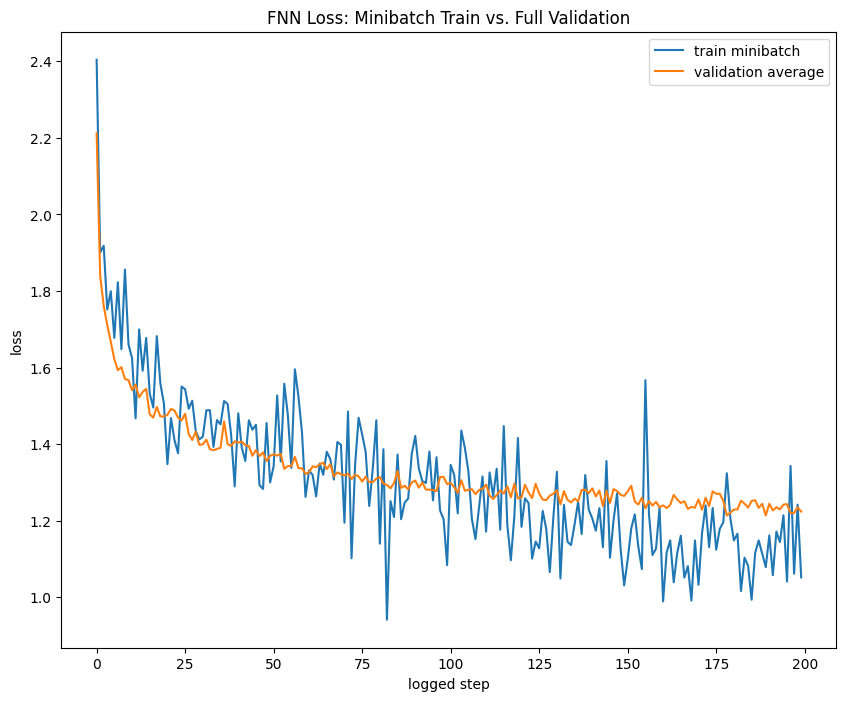

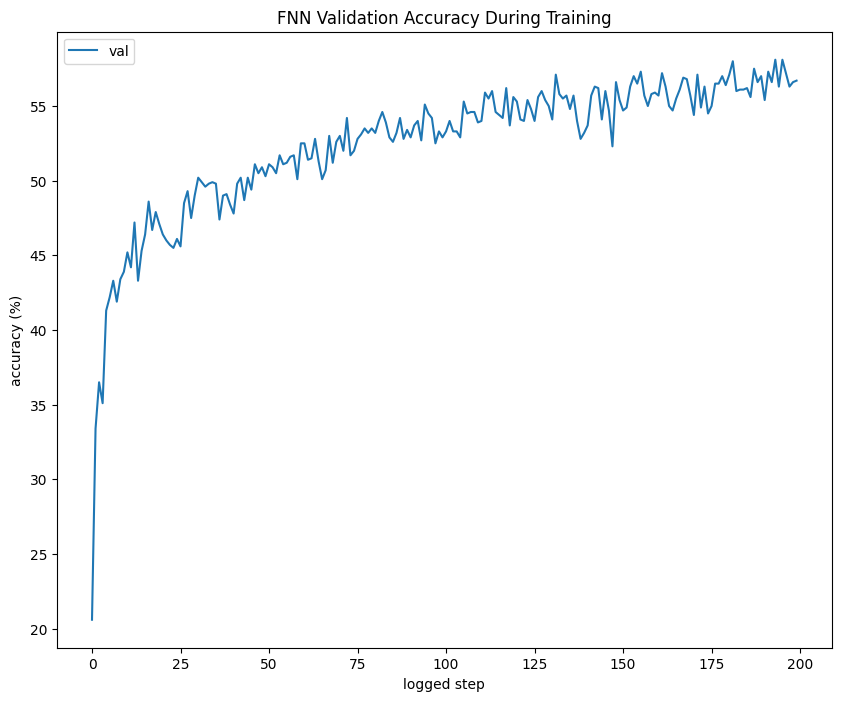

In [27]:
fig = plt.figure()
plt.plot(fnn_train_loss_history, label='train minibatch')
plt.plot(fnn_val_loss_history, label='validation average')
plt.title('FNN Loss: Minibatch Train vs. Full Validation')
plt.xlabel('logged step')
plt.ylabel('loss')
plt.legend()
fig.savefig('fnn_lossvstrain.png')

fig = plt.figure()
plt.plot(fnn_val_acc_history, label='val')
plt.title('FNN Validation Accuracy During Training')
plt.xlabel('logged step')
plt.ylabel('accuracy (%)')
plt.legend()
fig.savefig('fnn_valaccuracy.png')
plt.show()



## Part 2: Convolutional Neural Network

### Section 7: CNN Model


#### Question 7.1-7.2: CNN Module [code] (6 points each)

Implement the `CNN` class below: given `im_size=(3, 32, 32)`,
`hidden_dim`, `kernel_size` (width/height of the square conv filters), and
`n_classes=10`, `forward(images)` should return a `(N, n_classes)` score
tensor. A few lines (e.g. `conv -> relu -> (optionally) pool -> affine`) are
enough.

**Implementation Guide and Point Breakdown**

A recommended introductory architecture is
`Conv2d -> ReLU -> MaxPool2d -> Flatten -> Linear`.

1. **Question 7.1 — Module initialization (6 points):**
   * Split `im_size` into input
   channels, height, and width.
   * The first convolution maps the image channels to
   `hidden_dim` output channels. For an odd kernel, suitable padding can preserve
   spatial size.
   * Use `floor((input + 2*padding - kernel_size) / stride) + 1`
   rather than guessing the feature size.
   * After pooling, compute the flattened
   `(channels * height * width)` dimension required by the final Linear layer.
2. **Question 7.2 — Forward pass (6 points):**
   * Apply the modules in the intended
   order, flatten all non-batch dimensions, and return `(N, n_classes)` scores.
   * Do not apply softmax because `cross_entropy` handles it internally.

> **Debugging tip:** Pass a dummy input through one operation at a time and print
> each shape before defining the Linear input size. Start with `kernel_size=3`.

In [28]:
class CNN(nn.Module):
    def __init__(self, im_size, hidden_dim, kernel_size, n_classes):
        '''
        Create the components of a CNN classifier. PyTorch's default parameter
        initialization is acceptable unless you choose to initialize manually.

        Arguments:
            im_size (tuple): A tuple of ints with (channels, height, width)
            hidden_dim (int): Number of hidden activations to use (number of
                convolutional filters / size of the hidden fully-connected layer --
                up to you how you use it)
            kernel_size (int): Width and height of (square) convolution filters
            n_classes (int): Number of classes to score
        '''
        super(CNN, self).__init__()
        #############################################################################
        # TODO 7.1 (6 points): Initialize the convolution, optional pooling, and
        # classification layers. Ensure the Linear input dimension matches the
        # flattened feature-map size. PyTorch's default initialization is valid.
        #############################################################################
        C, H, W = im_size
        self.conv1 = nn.Conv2d(C, hidden_dim, kernel_size, padding=kernel_size // 2)  # keeps H, W for odd k
        self.pool = nn.MaxPool2d(2, 2)                                                # H, W -> H/2, W/2
        self.fc = nn.Linear(hidden_dim * (H // 2) * (W // 2), n_classes)
        #############################################################################
        #                             END OF YOUR CODE                              #
        #############################################################################

    def forward(self, images):
        '''
        Take a batch of images and run them through the CNN to
        produce a score for each class.

        Arguments:
            images (Tensor): A tensor of size (N, C, H, W) where
                N is the batch size
                C is the number of channels
                H is the image height
                W is the image width

        Returns:
            A tensor of size (N, n_classes) specifying the score
            for each example and category.
        '''
        scores = None
        #############################################################################
        # TODO 7.2 (6 points): Implement the forward pass.
        #############################################################################
        x = F.relu(self.conv1(images))   # (N, hidden_dim, H, W)
        x = self.pool(x)                 # (N, hidden_dim, H/2, W/2)
        x = x.reshape(x.size(0), -1)     # (N, hidden_dim*H/2*W/2)
        scores = self.fc(x)              # (N, n_classes)
        #############################################################################
        #                             END OF YOUR CODE                              #
        #############################################################################
        return scores


### Section 8: CNN Hyperparameters and Optimizer


#### Question 8.1-8.2: CNN Configuration and Optimizer [code] (3 points, 2 points)
Tune the hyperparameters and initialize an optimizer from
`torch.optim`.

**Experiment Guide and Point Breakdown**

- **Question 8.1 — Configuration and tuning (3 points):**
  * Begin with a baseline using
  `kernel_size=3`, a moderate number of filters, and pooling. Change one setting
  at a time and compare validation accuracy.
  * Lower the learning rate if the loss
  diverges; consider weight decay if the model overfits; increase training time
  or capacity if both training and validation accuracy remain low.
  * Evaluate the
  test set only after selecting the final configuration.
- **Question 8.2 — Optimizer (2 points):**
  * Pass `cnn_model.parameters()` and the
  relevant learning rate, momentum, and weight decay values to the optimizer.
  * Adam is also acceptable if you record the selected settings.

> Suggested search ranges: `16–64` filters, batch size `64–256`, `5–15` epochs,
> SGD learning rate `1e-3–1e-1`, and momentum `0.9`.

In [29]:
#############################################################################
# TODO 8.1 (3 points): Tune hyperparameters such as hidden dimensionality,
# kernel size, epochs, weight decay, momentum, batch size, and learning rate.
# Use validation accuracy to select a configuration whose loss decreases and
# whose accuracy improves clearly over random guessing (10% for CIFAR-10).
#############################################################################
cnn_hidden_dim = 32
cnn_kernel_size = 3
cnn_epochs = 8
cnn_weight_decay = 5e-4
cnn_momentum = 0.9
cnn_batch_size = 128
cnn_lr = 0.01
#############################################################################
#                             END OF YOUR CODE                              #
#############################################################################

cnn_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=cnn_batch_size, shuffle=True)
cnn_val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=cnn_batch_size, shuffle=False)
cnn_test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=cnn_batch_size, shuffle=False)

cnn_model = CNN(im_size, cnn_hidden_dim, cnn_kernel_size, n_classes).to(device)
criterion = F.cross_entropy

#############################################################################
# TODO 8.2 (2 points): Initialize an optimizer from torch.optim using the
# hyperparameters above. This only requires one line.
#############################################################################
optimizer = torch.optim.SGD(cnn_model.parameters(), lr=cnn_lr, momentum=cnn_momentum, weight_decay=cnn_weight_decay)
#############################################################################
#                             END OF YOUR CODE                              #
#############################################################################


### Section 9: CNN Training

#### Question 9.1: CNN Training Loop [code] (7 points)

Use the same training procedure as Question 6.1, now applied to `cnn_model`.

**Implementation Guide**

Use the same five steps as Question 6.1 with `cnn_model`, `cnn_train_loader`, and
the CNN optimizer. When adapting the FNN loop, verify that no FNN model, loader,
or optimizer reference remains.

- Call `cnn_model.train()` before processing training batches.
- Score shape is `(batch_size, n_classes)` and target shape is `(batch_size,)`.
- Confirm that the first loss is finite before running all epochs.
- Run validation without gradients using the provided `evaluate` helper.

> **Quick sanity check:** Before training, loss for a 10-class problem may be near
> `log(10)`. If it does not change for several steps, inspect gradient flow and
> the optimizer's parameter connection.

In [30]:
cnn_train_loss_history, cnn_val_loss_history, cnn_val_acc_history = [], [], []
log_interval = 10

for epoch in range(1, cnn_epochs + 1):
    cnn_model.train()
    for batch_idx, (images, targets) in enumerate(cnn_train_loader):
        images, targets = images.to(device), targets.to(device)
        #############################################################################
        # TODO 9.1 (7 points): Update `cnn_model` using `optimizer`.
        # This only requires a few lines: zero the gradients, run the forward
        # pass, compute the loss with `criterion`, backpropagate, and step the
        # optimizer. Store the scalar loss for this batch in a variable called
        # `loss` (needed for logging below).
        #############################################################################
        optimizer.zero_grad()
        output = cnn_model(images)
        loss = criterion(output, targets)
        loss.backward()
        optimizer.step()
        #############################################################################
        #                             END OF YOUR CODE                              #
        #############################################################################
        if batch_idx % log_interval == 0:
            val_loss, val_acc = evaluate(cnn_model, criterion, cnn_val_loader)
            cnn_train_loss_history.append(loss.item())
            cnn_val_loss_history.append(val_loss)
            cnn_val_acc_history.append(val_acc)
            print('Train Epoch: {} [{}/{}]\tTrain Minibatch Loss: {:.6f}\tVal Loss: {:.6f}\tVal Acc: {:.2f}%'.format(
                epoch, batch_idx * len(images), len(cnn_train_loader.dataset), loss.item(), val_loss, val_acc))

test_loss, test_acc = evaluate(cnn_model, criterion, cnn_test_loader)
print('\nTest set: Average loss: {:.4f}, Accuracy: {:.2f}%'.format(test_loss, test_acc))


Train Epoch: 1 [0/49000]	Train Minibatch Loss: 2.288341	Val Loss: 2.257685	Val Acc: 14.40%


Train Epoch: 1 [1280/49000]	Train Minibatch Loss: 1.888900	Val Loss: 1.925174	Val Acc: 34.30%


Train Epoch: 1 [2560/49000]	Train Minibatch Loss: 1.719449	Val Loss: 1.803892	Val Acc: 35.10%


Train Epoch: 1 [3840/49000]	Train Minibatch Loss: 1.731781	Val Loss: 1.731185	Val Acc: 38.80%


Train Epoch: 1 [5120/49000]	Train Minibatch Loss: 1.624188	Val Loss: 1.647846	Val Acc: 43.70%


...

Train Epoch: 8 [44800/49000]	Train Minibatch Loss: 0.636228	Val Loss: 1.016369	Val Acc: 65.00%


Train Epoch: 8 [46080/49000]	Train Minibatch Loss: 0.800156	Val Loss: 1.015358	Val Acc: 65.50%


Train Epoch: 8 [47360/49000]	Train Minibatch Loss: 0.725066	Val Loss: 1.060449	Val Acc: 64.60%


Train Epoch: 8 [48640/49000]	Train Minibatch Loss: 1.102480	Val Loss: 1.024332	Val Acc: 65.00%



Test set: Average loss: 1.0998, Accuracy: 63.47%


#### Provided: Learning curves

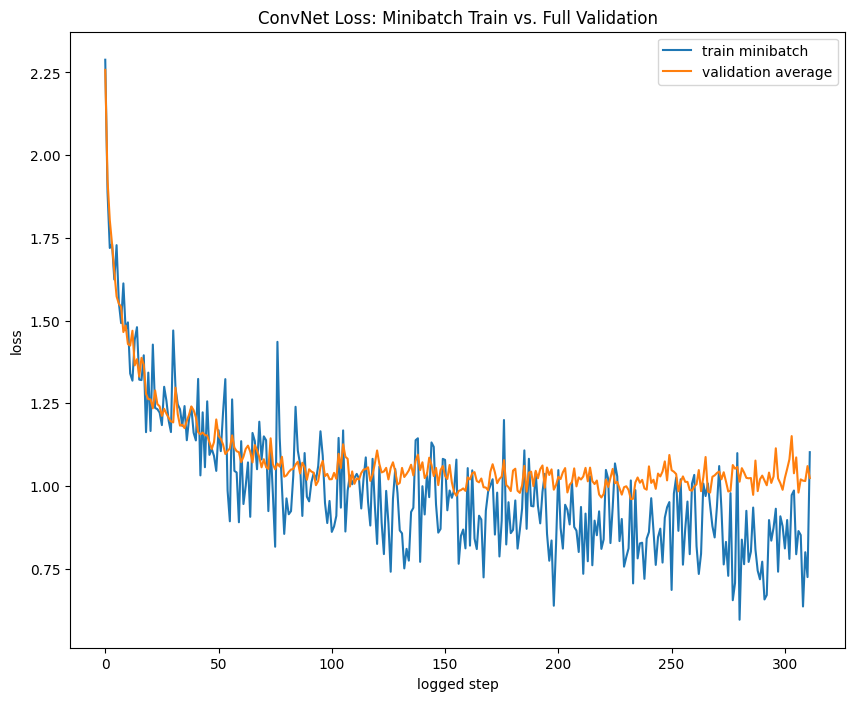

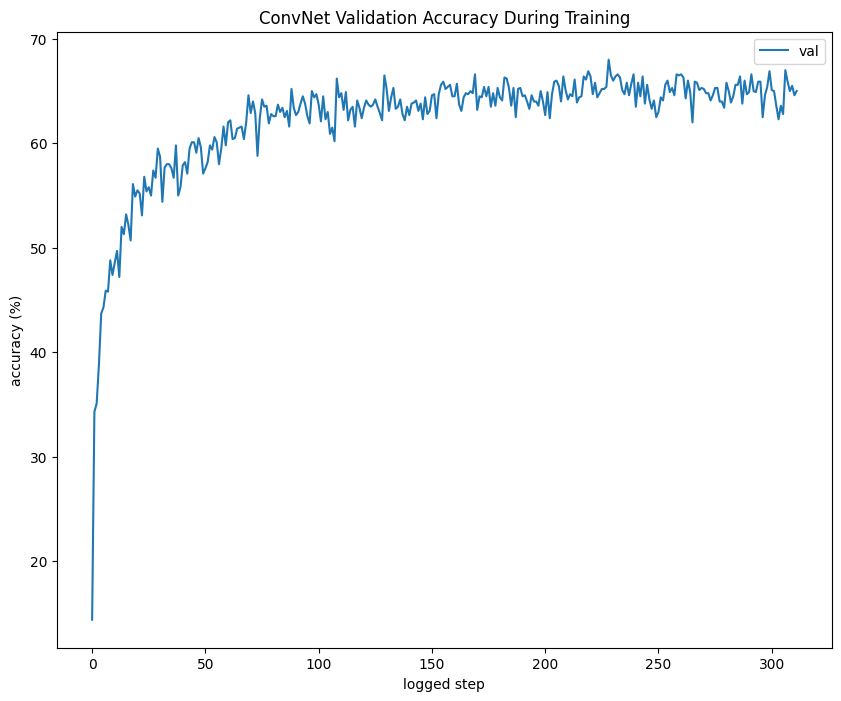

In [31]:
fig = plt.figure()
plt.plot(cnn_train_loss_history, label='train minibatch')
plt.plot(cnn_val_loss_history, label='validation average')
plt.title('ConvNet Loss: Minibatch Train vs. Full Validation')
plt.xlabel('logged step')
plt.ylabel('loss')
plt.legend()
fig.savefig('convnet_lossvstrain.png')

fig = plt.figure()
plt.plot(cnn_val_acc_history, label='val')
plt.title('ConvNet Validation Accuracy During Training')
plt.xlabel('logged step')
plt.ylabel('accuracy (%)')
plt.legend()
fig.savefig('convnet_valaccuracy.png')
plt.show()


### Section 10: Filter Visualization

#### Question 10.1: Visualize the Trained Filters [code] (3 points)

Extract the first convolutional layer's weights from the trained `cnn_model`
and turn it into a numpy array of shape `(hidden_dim, kernel_size, kernel_size, 3)`.

**Implementation Guide**

A PyTorch convolution weight has shape `(out_channels, in_channels, H, W)`.
The visualization function expects channel-last shape `(filters, H, W, channels)`.

1. Read `.weight` from the first `Conv2d` module created in `CNN.__init__`.
2. Detach it from the computation graph, move it to CPU, and convert to NumPy.
3. Reorder axes to `(0, 2, 3, 1)` with `transpose`.
4. Print `w.shape` and verify it before visualization.

> `.numpy()` cannot be called directly on a GPU/MPS Tensor. Move it to CPU first,
> and prefer `detach()` over the legacy `.data` approach.

w shape: (32, 3, 3, 3)
figure saved as a grid!


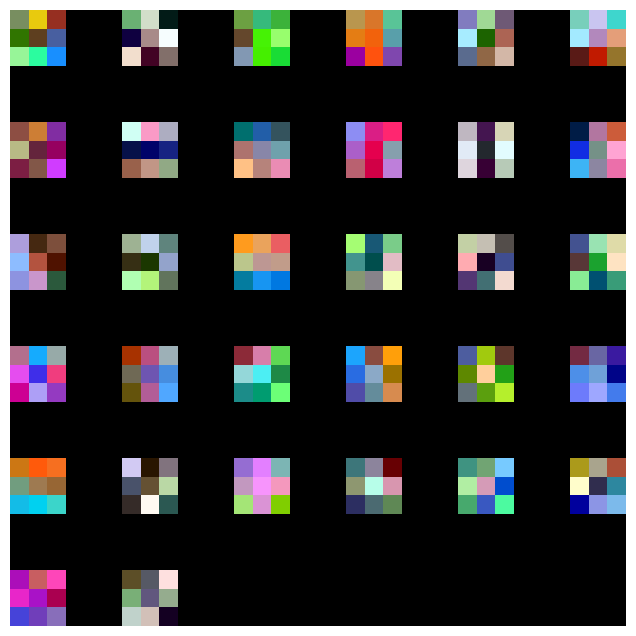

In [32]:
from math import sqrt, ceil


def visualize_grid(Xs, ubound=255.0, padding=1):
    '''Reshape a 4D tensor of image data (N, H, W, C) to a grid for easy visualization.'''
    (N, H, W, C) = Xs.shape
    grid_size = int(ceil(sqrt(N)))
    grid_height = H * grid_size + padding * (grid_size - 1)
    grid_width = W * grid_size + padding * (grid_size - 1)
    grid = np.zeros((grid_height, grid_width, C))
    next_idx = 0
    y0, y1 = 0, H
    for y in range(grid_size):
        x0, x1 = 0, W
        for x in range(grid_size):
            if next_idx < N:
                img = Xs[next_idx]
                low, high = np.min(img), np.max(img)
                value_range = high - low
                if value_range > 0:
                    grid[y0:y1, x0:x1] = ubound * (img - low) / value_range
                else:
                    grid[y0:y1, x0:x1] = 0
                next_idx += 1
            x0 += W + padding
            x1 += W + padding
        y0 += H + padding
        y1 += H + padding
    return grid


# collect the first conv layer's weights
w = None
#############################################################################
# TODO 10.1 (3 points): Extract the first convolutional layer's weight tensor
# from `cnn_model`, convert it to a numpy array with shape
# (hidden_dim, kernel_size, kernel_size, 3) -- (filters, H, W, C) -- and
# assign it to `w`. This depends on what you named the conv layer in
# CNN.__init__ above. If it is named `conv1`, start from
# `cnn_model.conv1.weight`, then detach it, move it to CPU, convert it to
# NumPy, and reorder axes from (out_channels, in_channels, H, W) to
# (filters, H, W, channels). Do not use the legacy `.data` attribute.
#############################################################################
w = cnn_model.conv1.weight.detach().cpu().numpy()   # (hidden_dim, 3, k, k)
w = w.transpose(0, 2, 3, 1)                          # (hidden_dim, k, k, 3)
print('w shape:', w.shape)
#############################################################################
#                             END OF YOUR CODE                              #
#############################################################################

plt.imsave('convnet_gridfilt.png', visualize_grid(w, padding=3).astype('uint8'))
plt.imshow(visualize_grid(w, padding=3).astype('uint8'))
plt.gca().axis('off')
print('figure saved as a grid!')


### Section 11: FNN vs. CNN Analysis

#### Question 11.1: FNN vs. CNN Analysis [written] (6 points)

---

You just trained two different architectures, `fnn_model` and `cnn_model`, on
the exact same CIFAR-10 images.

1. Compare their final test-set accuracies (printed above) and their
   training/validation curves. Which model performed better, and by how much?
2. Why would you generally expect a CNN to outperform a similarly-sized FNN
   on image data? Discuss translation equivariance in convolution and the limited
   translation tolerance introduced by pooling. Explain why a CNN is not perfectly
   translation invariant, considering boundaries, padding, and stride.
3. (Optional) Compare the number of trainable parameters in each model, e.g.
   `sum(p.numel() for p in fnn_model.parameters())` vs.
   `sum(p.numel() for p in cnn_model.parameters())`. Does the parameter count
   difference match which model performed better, or does one model do more
   with fewer parameters?

---

$\color{blue}{\textit Your Answer:}$
<!-- ANSWER_START: 11.1 -->
1. The CNN reached 63.47% test accuracy, while the FNN got 56.43%, so the CNN was about 7.04 percentage points better. The learning curves show the same trend. At the end of training, the CNN had a lower validation loss (about 1.02 vs 1.22) and a higher validation accuracy (about 65% vs 57%).

2. In an image, nearby pixels are closely related, and the same kind of pattern (like an edge) can show up anywhere. A conv layer only looks at a small region at a time and reuses the same filter over the whole image. Because of this weight sharing, a CNN needs far fewer parameters per feature, so with the same parameter budget it can learn many more useful local filters. An FNN connects every pixel to every hidden unit, so it spends its parameters on learning the same pattern separately for each position. That is why, with a similar number of parameters, a CNN usually generalizes better on images.

Since the same filter is used everywhere, convolution is translation equivariant. If an object in the image moves, its features in the feature map move by the same amount. This is equivariance, not invariance: the features move with the object instead of staying the same. Max pooling adds a little invariance. If a feature moves but stays inside the same pooling window, the maximum stays the same, so the output does not change. But if it moves into a different window, the output changes, so this tolerance only works for small shifts.

A CNN is also not perfectly translation invariant because of boundaries and stride. Near the borders the filter sees zero padding, so the same pattern gives a different response at the edge than in the center, and part of the object can move out of the image. Also, with a stride larger than 1 (for example, 2x2 pooling with stride 2), the output only exists on a coarser grid, so moving the input by just one pixel can change which window a feature falls into and change the output.

3. The FNN has 1,708,810 parameters and the CNN has only 82,826, which is about 20 times fewer. Even with far fewer parameters, the CNN performed better. This is because weight sharing matches the structure of image data well, so the CNN can use its parameters much more efficiently.
<!-- ANSWER_END: 11.1 -->

---